In [2]:
# Imports to enable plotting functionality
import numpy as np
import matplotlib.pyplot as plt
import bz2
import pickle
import _pickle as cPickle
import os 

## functions to enable loading of the pickle files

In [2]:
# Pickle a file and then compress it into a file with extension 
def compressed_pickle(title, data):
    with bz2.BZ2File(title + '.pbz2', 'w') as f: 
        cPickle.dump(data, f)

# Load any compressed pickle file
def decompress_pickle(file):
    data = bz2.BZ2File(file+'.pbz2', 'rb')
    data = cPickle.load(data)
    return data

def findData(electrode, dir_path):
    substring = str(electrode[0])+'_'+str(electrode[1])+'_'+str(electrode[2])
    matching_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if substring in file:
                matching_files.append(file)
    
    currents = []
    thresholds = []

    for file in matching_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        currents.append(data[0])
        thresholds.append(data[1])
        
    return currents,thresholds

def findInitData(electrode, dir_path):
    substring = str(electrode[0])+'_'+str(electrode[1])+'_'+str(electrode[2])
    matching_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if substring in file:
                matching_files.append(file)
    
    currents = []
    thresholds = []
    init_seg = []
    init_time = []

    for file in matching_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        currents.append(data[0])
        thresholds.append(data[1])
        init_seg.append(data[2])
        init_time.append(data[3])
        
    return currents,thresholds,init_seg,init_time

def truncate_lists(X, Y, threshold):
    # Use list comprehension to filter out indices where Y >= threshold
    X_truncated = [x for x, y in zip(X, Y) if np.abs(y) >= threshold]
    Y_truncated = [y for y in Y if np.abs(y) >= threshold]
    return X_truncated, Y_truncated

def truncate_lists_init(X, Y, S, T, threshold):
    # Use list comprehension to filter out indices where Y >= threshold
    X_truncated = [x for x, y in zip(X, Y) if np.abs(y) >= threshold]
    S_truncated = [s for s, y in zip(S, Y) if np.abs(y) >= threshold]
    T_truncated = [t for t, y in zip(T, Y) if np.abs(y) >= threshold]
    Y_truncated = [y for y in Y if np.abs(y) >= threshold]
    
    return X_truncated, Y_truncated, S_truncated, T_truncated

## Plot spike init data

In [62]:
dir_path = '/Volumes/Lab/Users/vilkhu/data-backup/sim-data/elecPitch/triphasic/radial/elecPitch_100um/'

# Output the electrodes files 
filename = dir_path+'electrodes.pkl'
data = decompress_pickle(filename)
print('Electrodes: ',data)

# Find data files in dir
data_files = []
for root,dirs,files in os.walk(dir_path):
    for file in files:
        if '_' in file:
            data_files.append(file)

# Next, extract data
i1 = []
i2 = []
spikes = []
init_segs = []
for file in data_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        
        # Output substring before '_' in file
        curr1 = round(float(file.split('_')[0]),2)
        curr2 = round(float(file.split('_')[1][:-9]),2)
        # if curr1 < -1 and curr1 > -1.5 and curr2 > -0.8:
        if curr1 < 7 and curr1 > -7 and curr2 < 7 and curr2 > -7:
            i1.append(round(float(file.split('_')[0]),2))
            i2.append(round(float(file.split('_')[1][:-9]),2))
            spikes.append(data[0])
            init_segs.append(data[1])

Electrodes:  [[-1030 0 42]
 [-930 0 42]]


In [63]:
# unroll list of lists
init_segs_unroll = [item for sublist in init_segs for item in sublist]

In [64]:
# Make list of unique segments, these are the bins
bins = np.unique(init_segs_unroll)
print('List of unique segs:\n', bins)

List of unique segs:
 [145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179]


In [65]:
# make an empty list of zeros of same length as bins
counts = np.zeros(len(bins))
print(counts)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [66]:
# Also calculate center of mass 
COM = []

# march through init_segs, adjusting spike count normalized by number of spiking segs
counts = np.zeros(len(bins))
for lst in init_segs:
    # If spiking
    if len(lst) > 0:
        COM.append(np.mean(lst))
        normalized_spike = 1/len(lst)
        for seg in lst:
           # Find index of seg in bins and normalized_spike to same counts idx 
           idx = np.argwhere(bins == seg)[0][0]
           counts[idx] += normalized_spike
    else:
        COM.append(300)


In [67]:
print(len(i1))
print(len(COM))
print(COM)

120
120
[171.5, 166.0, 171.0, 157.5, 152.5, 171.5, 152.5, 151.5, 171.5, 155.0, 172.0, 162.0, 156.5, 152.0, 171.5, 170.0, 153.0, 169.5, 171.0, 171.5, 155.0, 159.0, 171.5, 159.0, 161.5, 155.0, 162.0, 164.0, 152.0, 171.0, 161.5, 167.5, 152.0, 152.0, 158.5, 171.0, 152.5, 151.5, 153.0, 156.5, 152.0, 163.5, 158.0, 156.5, 152.0, 165.0, 152.0, 152.5, 171.5, 163.5, 172.0, 160.5, 162.0, 171.5, 172.0, 172.0, 152.0, 152.0, 171.0, 171.5, 165.0, 171.0, 153.0, 169.0, 172.0, 171.0, 163.0, 171.0, 160.0, 165.0, 168.5, 172.0, 170.0, 172.0, 171.5, 152.5, 153.0, 162.5, 154.0, 171.0, 161.5, 152.0, 168.5, 169.0, 151.5, 167.0, 156.0, 166.0, 152.0, 167.5, 152.0, 171.5, 164.0, 155.5, 153.0, 152.0, 171.5, 152.0, 152.0, 151.5, 152.0, 172.0, 172.0, 160.5, 156.5, 171.0, 154.0, 152.5, 152.5, 154.0, 167.5, 167.5, 161.5, 170.0, 152.0, 171.5, 162.5, 160.0, 153.0, 172.0]


In [68]:
np.min(COM)

151.5

In [69]:
print(len(bins))
print(len(COM))
print(len(counts))

35
120
35


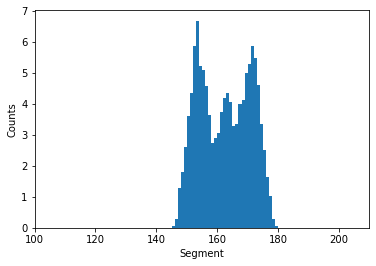

In [70]:
# Plot the histogram from pre-counted data
plt.bar(bins, counts, width=1, align='edge')

# Adding labels and title
plt.xlabel('Segment')
plt.ylabel('Counts')
plt.xlim([100,210])
# plt.xlim([140,200])

# Show the plot
plt.show()

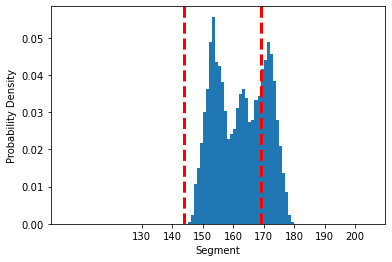

In [71]:
total_counts = sum(counts)
# total_counts = 2412.0
bin_width = bins[1] - bins[0]
normalized_counts = [count / (total_counts * bin_width) for count in counts]
# Plot the normalized histogram from pre-counted data
plt.bar(bins, normalized_counts, width=1, align='edge')

# Adding labels and title
plt.xlabel('Segment')
plt.ylabel('Probability Density')
plt.xlim([100, 210])
# plt.xlim([140, 200])
# plt.ylim([0,0.19])
# plot xticks every 1
plt.xticks(np.arange(130, 210, 10))
# plt.yticks(np.arange(0, 0.19, 0.02))
plt.axvline(144, color='r', linewidth=3, linestyle='--')
plt.axvline(169, color='r', linewidth=3, linestyle='--')
# plt.xticks(np.arange(140, 200, 1))
# plt.savefig("figure4_A_triphasic_hist.pdf",format="pdf", bbox_inches="tight")
plt.show()

In [72]:
print(total_counts)

119.99999999999999


In [73]:
# Try rounding ceiling function on COM
COM_round = [np.ceil(com) for com in COM]
print(COM_round)

[172.0, 166.0, 171.0, 158.0, 153.0, 172.0, 153.0, 152.0, 172.0, 155.0, 172.0, 162.0, 157.0, 152.0, 172.0, 170.0, 153.0, 170.0, 171.0, 172.0, 155.0, 159.0, 172.0, 159.0, 162.0, 155.0, 162.0, 164.0, 152.0, 171.0, 162.0, 168.0, 152.0, 152.0, 159.0, 171.0, 153.0, 152.0, 153.0, 157.0, 152.0, 164.0, 158.0, 157.0, 152.0, 165.0, 152.0, 153.0, 172.0, 164.0, 172.0, 161.0, 162.0, 172.0, 172.0, 172.0, 152.0, 152.0, 171.0, 172.0, 165.0, 171.0, 153.0, 169.0, 172.0, 171.0, 163.0, 171.0, 160.0, 165.0, 169.0, 172.0, 170.0, 172.0, 172.0, 153.0, 153.0, 163.0, 154.0, 171.0, 162.0, 152.0, 169.0, 169.0, 152.0, 167.0, 156.0, 166.0, 152.0, 168.0, 152.0, 172.0, 164.0, 156.0, 153.0, 152.0, 172.0, 152.0, 152.0, 152.0, 152.0, 172.0, 172.0, 161.0, 157.0, 171.0, 154.0, 153.0, 153.0, 154.0, 168.0, 168.0, 162.0, 170.0, 152.0, 172.0, 163.0, 160.0, 153.0, 172.0]


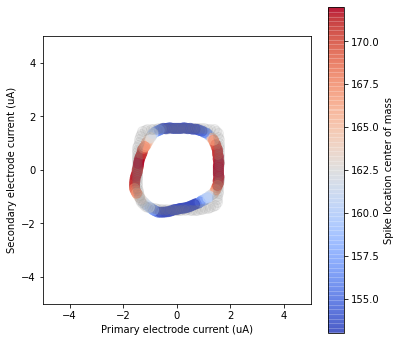

In [74]:
import matplotlib.colors as mcolors

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

# # Create color_map from spikes where spikes=1 is red and spikes=0 is black
# color_map = ['black' if x == 0 else 'red' for x in spikes] 

# # fix the polarity to match jepson figure
# i1_fix = [-x for x in i1]
# i2_fix = [-x for x in i2]

# Define the colormap
# cmap = plt.cm.get_cmap('RdBu')
cmap = plt.cm.get_cmap('coolwarm')

# vmin = 144
# vmax = 172

vmin = 153 # 167 --> 133(200)
vmax = 172

sc = ax.scatter(i1,i2,c=COM,cmap=cmap,vmin=vmin,vmax=vmax,s=100,alpha=0.7)
ax.scatter(i1_200um,i2_200um,c='grey',s=100,alpha=0.1)
# sc = ax.scatter(i1,i2,c=COM,cmap=custom_cmap,vmin=vmin,vmax=vmax,s=100,alpha=1)

ax.set_aspect('equal')
ax.set_xlabel('Primary electrode current (uA)')
ax.set_ylabel('Secondary electrode current (uA)')
# ax.set_ylabel('Secondary electrode current (uA)')
# ax.set_xlim(-0.01,1.8)
# ax.set_ylim(-0.01,1.8)
# ax.set_xlim(-7,7)
# ax.set_ylim(-7,7)
ax.set_xlim(-5,5)
ax.set_ylim(-5,5)


cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Spike location center of mass')

# ax.set_ylim(0,4.5)
# ax.set_ylim(0,np.max(i2_fix)+0.5)
# ax.set_ylim(-2,2)
## remove y axis labels
# ax.set_yticklabels([])
# ax.set_title('Multielec tradeoff \n (axon aligned at y=0um)\n distal axon, straddling')
plt.savefig("elecPitch_100_w200.pdf",format="pdf", bbox_inches="tight")
# ax.set_title('Single electrode stimulation, aligned electrode 12um away\n red = spike; blue = spike at lobes; black = no spike')

In [16]:
# Save data for 200um pitch case
i1_200um = i1
i2_200um = i2

Text(0, 0.5, 'Fractional deviation in threshold')

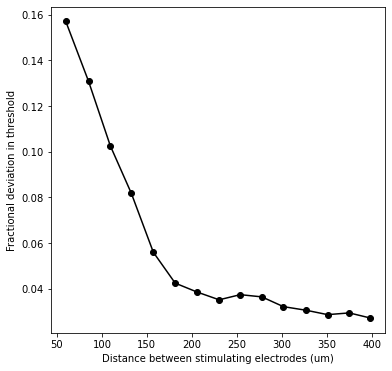

In [6]:
# Plot AJ data
# x = [47.117380109707476, 73.35072808218588, 98.50939058100184, 122.76903734704247, 148.1240366150852, 173.29992163751754, 198.33802647101882, 224.02369819249617, 248.37634658606527, 273.28700474480524, 298.14255082797285, 324.6824597208229, 349.2038888458326, 374.0938799762329, 398.23641358168214]
# y = [0.15513475475457178, 0.1260925690680948, 0.09468817685818992, 0.07158589301870756, 0.04298192303122801, 0.027997824914778698, 0.023698832947971597, 0.019887635828588664, 0.022387384505716455, 0.021311037186646075, 0.016565832883998502, 0.014790579504848246, 0.01267626872355398, 0.013523912228914012, 0.011059348753895505]

x = [59.78082084741458, 85.072766697271, 109.32859291672364, 132.71766521458852, 157.1627825203649, 181.43521322107404, 205.57480807173135, 230.338731417632, 253.81746791428182, 277.8341896036413, 301.79777695298003, 327.3852825692016, 351.0267429821648, 375.02353929401653, 398.2997011193374]
y = [0.15708678366448067, 0.1308983853522115, 0.10257989924285978, 0.08174772711770266, 0.055954483887627526, 0.0424427759858901, 0.038566218099256505, 0.035129522621634525, 0.03738363719634, 0.03641305555284877, 0.032134131724857004, 0.03053332099042125, 0.0286267698274266, 0.02939112089882385, 0.027168734104440526]

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)
ax.plot(x,y,marker='o',color='black')
ax.set_xlabel('Distance between stimulating electrodes (um)')
ax.set_ylabel('Fractional deviation in threshold')

In [ ]:
x = [59.78082084741458, 85.072766697271, 109.32859291672364, 132.71766521458852, 157.1627825203649, 181.43521322107404, 205.57480807173135, 230.338731417632, 253.81746791428182, 277.8341896036413, 301.79777695298003, 327.3852825692016, 351.0267429821648, 375.02353929401653, 398.2997011193374]
y = [0.15708678366448067, 0.1308983853522115, 0.10257989924285978, 0.08174772711770266, 0.055954483887627526, 0.0424427759858901, 0.038566218099256505, 0.035129522621634525, 0.03738363719634, 0.03641305555284877, 0.032134131724857004, 0.03053332099042125, 0.0286267698274266, 0.02939112089882385, 0.027168734104440526]